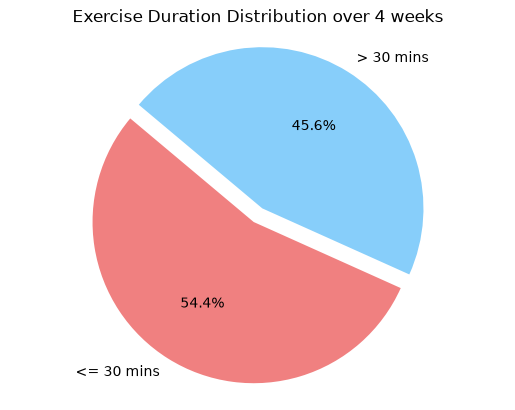

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import load_or_create_master_split_ids, run_model_experiment
predictors = ['V2AJ01a2','V2AJ01a1'] # Num minutes exercised, number times
# TODO: should we add V2AJ01a the categorical type of physical activity?
df = pd.read_csv("../../Data/V2A.csv", low_memory=False)
df = df[predictors + ['PublicID']]
df['V2AJ01a2'] = pd.to_numeric(df['V2AJ01a2'], errors='coerce')

# Filter to include only rows where exercise duration is more than 30 minutes (for data viz)
filtered_df = df[df['V2AJ01a2'] > 30]

# Count the number of times individuals exercised for more than 30 minutes
num_exercises_gt_30mins = filtered_df['V2AJ01a1'].count()

# Count the number of times individuals exercised for 30 minutes or less
num_exercises_lte_30mins = df['V2AJ01a1'].count() - num_exercises_gt_30mins

# Create a pie chart to visualize the distribution
labels = ['<= 30 mins', '> 30 mins']
sizes = [num_exercises_lte_30mins, num_exercises_gt_30mins]
colors = ['lightcoral', 'lightskyblue']
explode = (0, 0.1)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Exercise Duration Distribution over 4 weeks')

# Show the pie chart
plt.show()

In [2]:
df_outcomes = pd.read_csv('../../Data/Modified/Outcome.csv', usecols=['PublicID', 'MH_outcome'])

# Create the master split once and persist it for reuse in other notebooks.
split_path = 'master_split_ids.csv'
train_ids, test_ids = load_or_create_master_split_ids(df_outcomes, split_path)
df_outcomes

,PublicID,MH_outcome
0,00004O,1
1,00007I,1
2,00008G,0
3,00015J,0
4,00016H,1
...,...,...
7736,17349I,1
7737,17350A,1
7738,17351V,0
7739,17352T,1


In [3]:
df = pd.merge(df, df_outcomes, on='PublicID', how='inner')
df

,V2AJ01a2,V2AJ01a1,PublicID,MH_outcome
0,NaN,NaN,00004O,1
1,20.0,7,00007I,1
2,30.0,3,00008G,0
3,45.0,3,00015J,0
4,20.0,5,00016H,1
...,...,...,...,...
7603,60.0,1,17349I,1
7604,120.0,5,17350A,1
7605,NaN,NaN,17351V,0
7606,30.0,1,17352T,1


In [4]:
X = df.drop(['MH_outcome', 'PublicID'], axis=1)
y = df['MH_outcome']

train_df = df[df['PublicID'].isin(train_ids)].copy()
test_df = df[df['PublicID'].isin(test_ids)].copy()

X_train = train_df.drop(['MH_outcome', 'PublicID'], axis=1)
X_test = test_df.drop(['MH_outcome', 'PublicID'], axis=1)
y_train = train_df['MH_outcome']
y_test = test_df['MH_outcome']

y.value_counts()

MH_outcome
0    4517
1    3091
Name: count, dtype: int64

In [5]:
# Run the LR pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    predictors
)

Dropping rows with missing values because impute=False (train: 1615, test: 394).
Final dataset sizes for LR (impute=False): train=4469, test=1130
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found: {'classifier__C': 0.001, 'classifier__l1_ratio': 0.5}
Best CV Score (f1): 0.4486
Model Coefficients:
num__V2AJ01a2: 0.0
num__V2AJ01a1: 0.0
Evaluation Metrics for LR with shared preprocessing and adaptive CV scoring:
Accuracy: 0.5982
Precision (positive class): 0.0000
Recall (positive class): 0.0000
F1 (positive class): 0.0000
Macro Precision: 0.2991
Macro Recall: 0.5000
Macro F1: 0.3743
ROC AUC: 0.5000


In [6]:
# Run the RF pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    predictors
)

Dropping rows with missing values because impute=False (train: 1615, test: 394).
Final dataset sizes for RF (impute=False): train=4469, test=1130
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 600}
Best CV Score (f1): 0.4435
Feature Importances:
num__V2AJ01a2: 0.6816435874022927
num__V2AJ01a1: 0.3183564125977074
Evaluation Metrics for RF with shared preprocessing and adaptive CV scoring:
Accuracy: 0.5425
Precision (positive class): 0.4282
Recall (positive class): 0.4141
F1 (positive class): 0.4211
Macro Precision: 0.5216
Macro Recall: 0.5214
Macro F1: 0.5214
ROC AUC: 0.5296


In [7]:
# Run the XGBoost pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    predictors
)

Dropping rows with missing values because impute=False (train: 1615, test: 394).
Final dataset sizes for XGB (impute=False): train=4469, test=1130
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.001, 'classifier__max_depth': 4, 'classifier__n_estimators': 60, 'classifier__subsample': 0.8}
Best CV Score (f1): 0.4583
Feature Importances:
num__V2AJ01a2: 0.5330243110656738
num__V2AJ01a1: 0.4669756591320038
Evaluation Metrics for XGB with shared preprocessing and adaptive CV scoring:
Accuracy: 0.5363
Precision (positive class): 0.4239
Recall (positive class): 0.4295
F1 (positive class): 0.4267
Macro Precision: 0.5187
Macro Recall: 0.5188
Macro F1: 0.5187
ROC AUC: 0.5169


In [8]:
# Run the SVM pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    predictors
)

Dropping rows with missing values because impute=False (train: 1615, test: 394).
Final dataset sizes for SVM (impute=False): train=4469, test=1130
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'classifier__estimator__C': 10, 'classifier__estimator__gamma': 0.1, 'classifier__estimator__kernel': 'rbf'}
Best CV Score (f1): 0.4302
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and adaptive CV scoring:
Accuracy: 0.5283
Precision (positive class): 0.4088
Recall (positive class): 0.3899
F1 (positive class): 0.3991
Macro Precision: 0.5057
Macro Recall: 0.5056
Macro F1: 0.5054
ROC AUC: 0.5095
